# 🌋 Análisis Sísmico de Chile
**Proyecto de Portafolio**

Este notebook se conecta a la API del USGS (United States Geological Survey) para descargar, limpiar y analizar visualmente los sismos más recientes del país.

In [1]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de estilo
sns.set_theme(style="darkgrid", palette="mako")
print("Librerías importadas correctamente.")

Librerías importadas correctamente.


### 1. Extracción de Datos vía API

### 2. Transformación y Limpieza con Pandas

In [2]:
import requests
import pandas as pd
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="darkgrid", palette="mako")

# 1. Configurar la petición a la API del USGS
url = "https://earthquake.usgs.gov/fdsnws/event/1/query"

# Calculamos las fechas dinámicamente (hace 1 año exacto hasta hoy)
fecha_inicio = (datetime.now() - timedelta(days=365)).strftime('%Y-%m-%d')
fecha_fin = datetime.now().strftime('%Y-%m-%d')

print(f"Obteniendo sismos desde {fecha_inicio} hasta {fecha_fin}...")

# Parámetros (Bounding Box geográfico aproximado de Chile y magnitud mínima)
params = {
    "format": "geojson",
    "starttime": fecha_inicio,
    "endtime": fecha_fin,
    "minlatitude": -56.0,  # Sur de Chile
    "maxlatitude": -17.0,  # Norte de Chile
    "minlongitude": -80.0, # Océano Pacífico (frente a costas)
    "maxlongitude": -65.0, # Cordillera
    "minmagnitude": 4.0    # Filtramos microsismos para no sobrecargar
}

response = requests.get(url, params=params)

if response.status_code == 200:
    data = response.json()
    
    # 2. Transformar el formato GeoJSON a una lista plana de diccionarios
    sismos_lista = []
    for feature in data.get('features', []):
        props = feature['properties']
        coords = feature['geometry']['coordinates'] # El formato es [longitud, latitud, profundidad]
        
        sismos_lista.append({
            'lugar': props['place'],
            'magnitud': props['mag'],
            'fecha': pd.to_datetime(props['time'], unit='ms'), # El USGS entrega el tiempo en milisegundos
            'longitud': coords[0],
            'latitud': coords[1],
            'profundidad': coords[2]
        })
    
    # 3. Creación del DataFrame de Pandas
    df = pd.DataFrame(sismos_lista)
    print(f"¡Éxito! Se obtuvieron {len(df)} registros históricos para analizar.\n")
    
    display(df.info())
    display(df.head())
else:
    print(f"Error en la petición: {response.status_code}")

Obteniendo sismos desde 2025-08-12 hasta 2026-08-12...


¡Éxito! Se obtuvieron 820 registros históricos para analizar.

<class 'pandas.DataFrame'>
RangeIndex: 820 entries, 0 to 819
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   lugar        820 non-null    str           
 1   magnitud     820 non-null    float64       
 2   fecha        820 non-null    datetime64[ms]
 3   longitud     820 non-null    float64       
 4   latitud      820 non-null    float64       
 5   profundidad  820 non-null    float64       
dtypes: datetime64[ms](1), float64(4), str(1)
memory usage: 38.6 KB


None

,lugar,magnitud,fecha,longitud,latitud,profundidad
0,"64 km WNW of Ollagüe, Chile",4.2,2026-08-08 16:34:53.190,-68.8326,-21.0069,109.177
1,"49 km NNE of Camiña, Chile",4.4,2026-08-08 15:15:27.722,-69.2409,-18.9032,127.950
2,"86 km NE of San Pedro de Atacama, Chile",4.3,2026-08-08 14:20:51.000,-67.5975,-22.3681,197.198
3,"77 km WSW of San Antonio de los Cobres, Argentina",4.6,2026-08-08 12:44:22.647,-67.0572,-24.3920,163.582
4,"108 km W of San Antonio de los Cobres, Argentina",4.4,2026-08-08 06:06:41.571,-67.3807,-24.3551,190.698


### 3. Visualización de Datos (EDA)

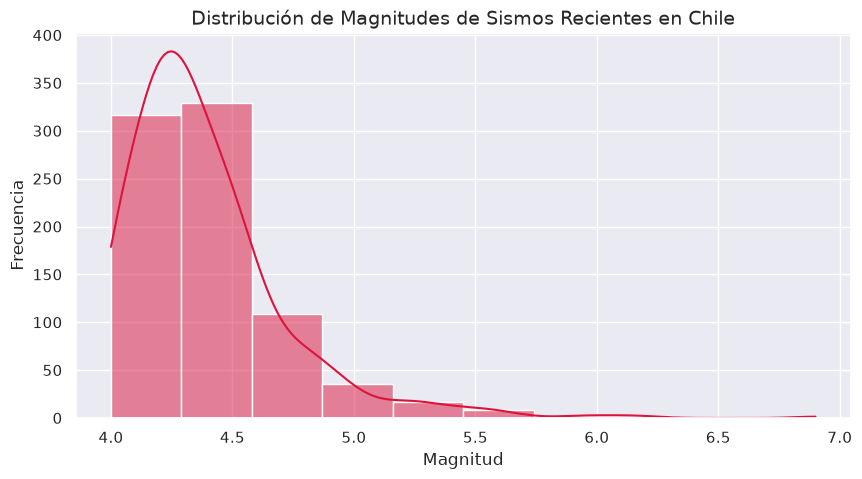

In [3]:
# Gráfico 1: Distribución de Magnitudes
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='magnitud', bins=10, kde=True, color="crimson")
plt.title('Distribución de Magnitudes de Sismos Recientes en Chile', fontsize=14)
plt.xlabel('Magnitud')
plt.ylabel('Frecuencia')
plt.show()

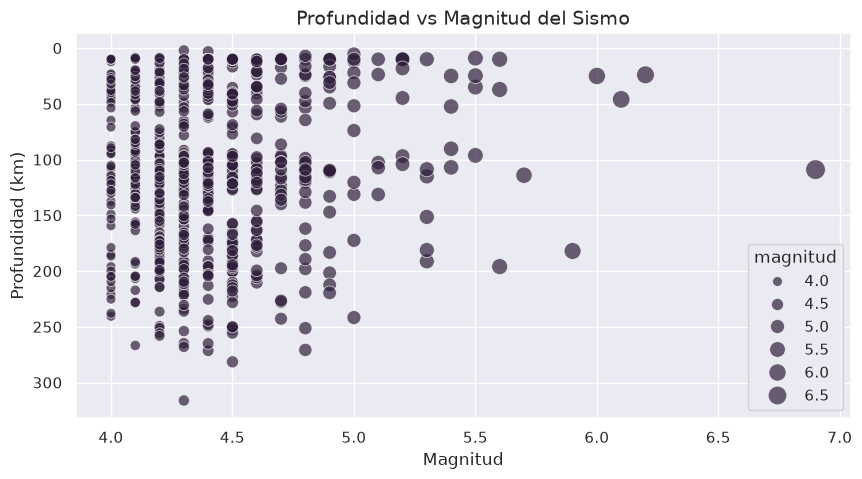

In [4]:
# Gráfico 2: Profundidad vs Magnitud
plt.figure(figsize=(10, 5))
sns.scatterplot(data=df, x='magnitud', y='profundidad', size='magnitud', sizes=(50, 200), alpha=0.7)
plt.gca().invert_yaxis()  # Invertir eje Y para simular profundidad subterránea
plt.title('Profundidad vs Magnitud del Sismo', fontsize=14)
plt.xlabel('Magnitud')
plt.ylabel('Profundidad (km)')
plt.show()

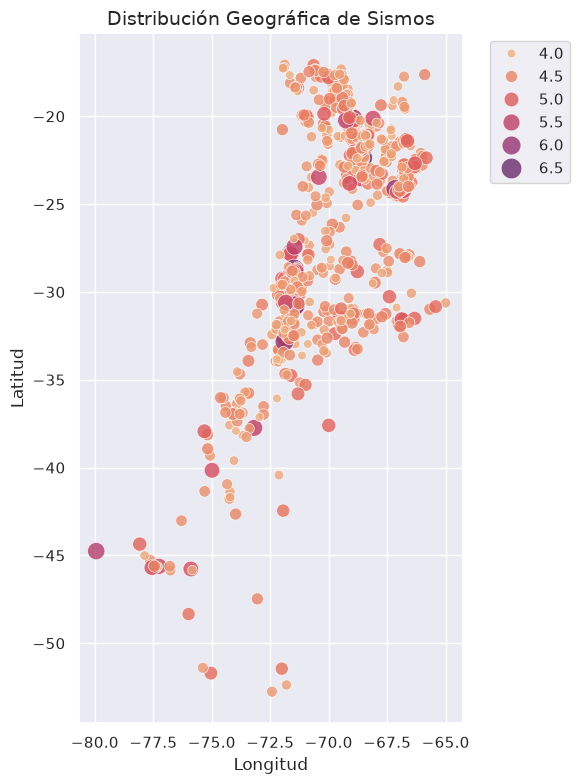

In [5]:
# Gráfico 3: Dispersión Geográfica de los Epicentros
plt.figure(figsize=(6, 8))
sns.scatterplot(data=df, x='longitud', y='latitud', hue='magnitud', size='magnitud', sizes=(40, 250), palette='flare', alpha=0.8)
plt.title('Distribución Geográfica de Sismos', fontsize=14)
plt.xlabel('Longitud')
plt.ylabel('Latitud')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()